# Flight Ticket Price Prediction - Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the dataset before performing any data cleaning or feature engineering.

EDA helps us to:

- Understand the structure of the dataset.
- Identify patterns and relationships between features.
- Detect outliers and unusual values.
- Understand the distribution of numerical and categorical variables.
- Generate business insights.
- Decide the preprocessing and feature engineering strategy.

**Dataset:** Clean_Dataset.csv

**Target Variable:** Price

In [15]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

# Set plot style
plt.style.use("ggplot")

# Default figure size
plt.rcParams["figure.figsize"] = (10, 5)

# Display settings
print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [16]:
# ==========================================
# Load Dataset
# ==========================================

# Read CSV File
df = pd.read_csv("Dataset/Clean_Dataset.csv")

# Display Dataset
display(df.head())

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [17]:
# ==========================================
# Data Preparation
# ==========================================

# Create a copy of the original dataset
eda_df = df.copy()

# Remove unnecessary column (if present)
if "Unnamed: 0" in eda_df.columns:
    eda_df.drop(columns="Unnamed: 0", inplace=True)

# Dataset shape after preparation
print(f"Dataset Shape : {eda_df.shape}")

# Display first Five Rows
display(eda_df.head())



Dataset Shape : (300153, 11)


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


# Numerical Feature Analysis

## Objective

In this step, we analyze all numerical features to understand their distribution and identify potential issues.

The analysis includes:

- Summary statistics
- Data distribution
- Outlier detection
- Skewness

**Numerical Features**

- Duration
- Days Left
- Price (Target Variable)

This analysis helps us decide whether any feature requires preprocessing before model building.

,count,mean,std,min,25%,50%,75%,max
duration,300153.0,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83
days_left,300153.0,26.004751,13.561004,1.00,15.00,26.00,38.00,49.00
price,300153.0,20889.660523,22697.767366,1105.00,4783.00,7425.00,42521.00,123071.00


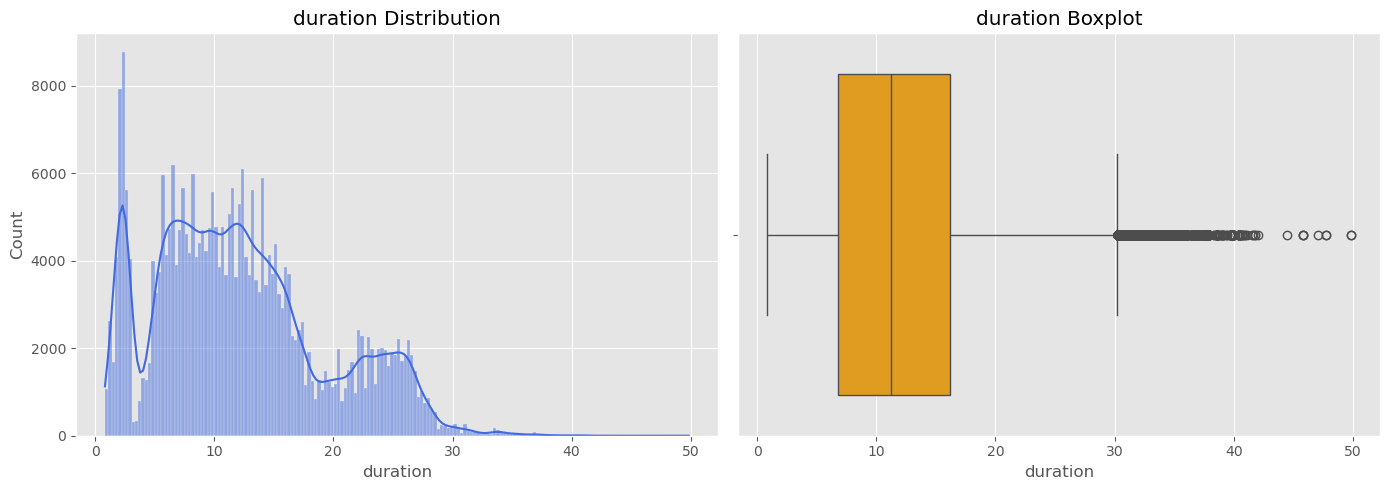

--------------------------------------------------------------------------------


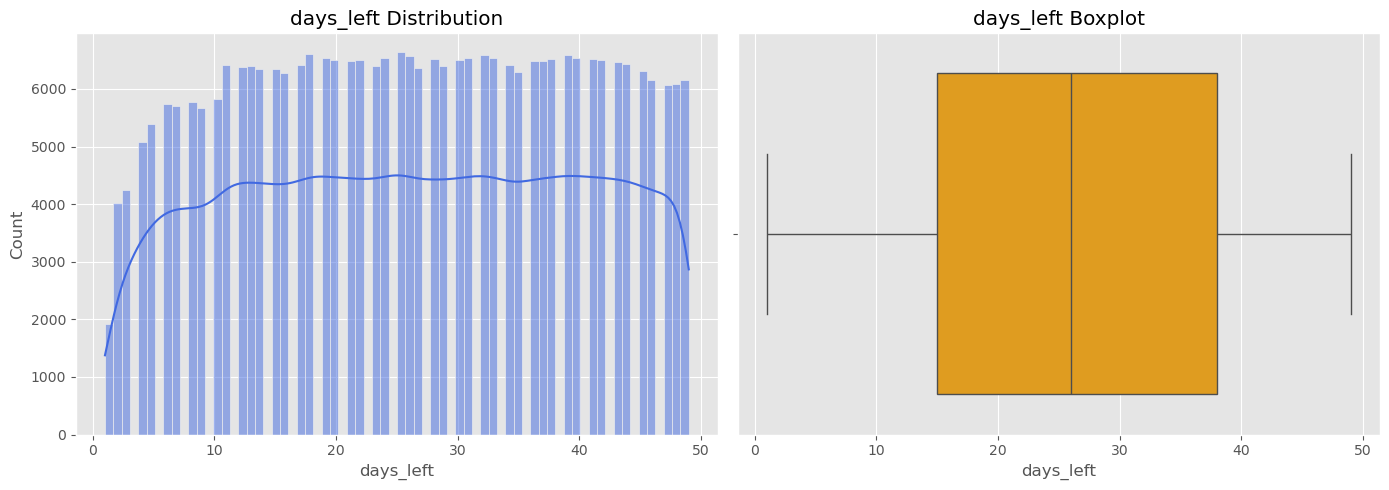

--------------------------------------------------------------------------------


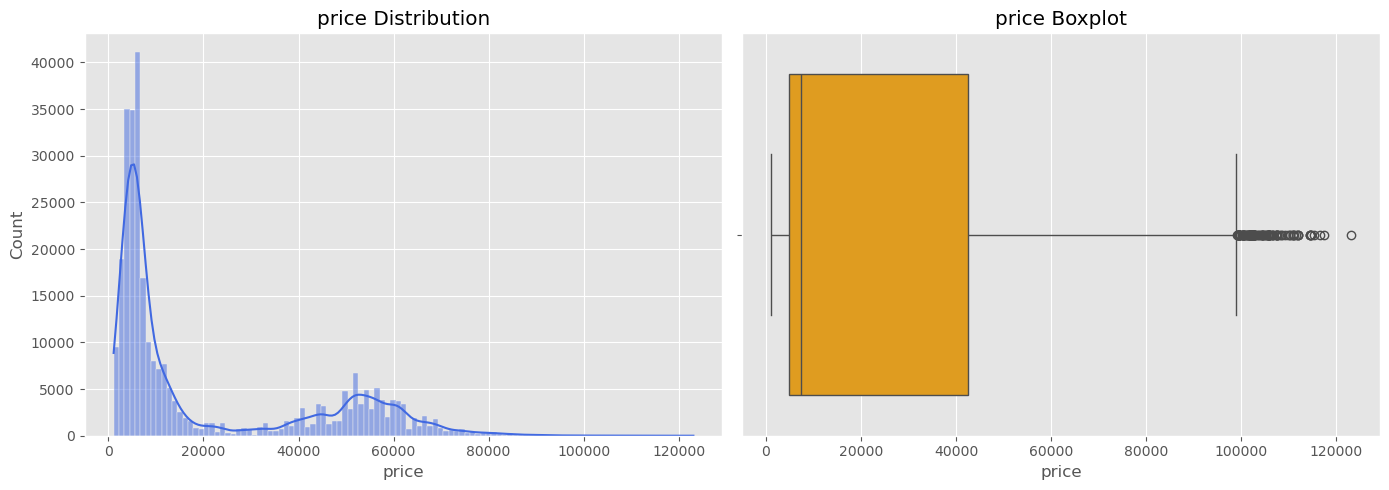

--------------------------------------------------------------------------------


In [18]:
# ==========================================
# Numerical Feature Analysis
# ==========================================

# Numerical Columns
num_cols = ["duration", "days_left", "price"]

# Summary Statistics 
display(eda_df[num_cols].describe().T)

# Distribution + Boxplot
for col in num_cols:

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram + KDE
    sns.histplot(
        eda_df[col],
        kde=True,
        ax=ax[0],
        color="royalblue"
    )

    ax[0].set_title(f"{col} Distribution")

    # Boxplot
    sns.boxplot(
        x=eda_df[col],
        color="orange"
    )

    ax[1].set_title(f"{col} Boxplot")

    plt.tight_layout()
    plt.show()

    print("-" * 80)

# Target Variable Analysis (Price)

## Objective

The target variable is the value that our Machine Learning model will predict.

In this step, we analyze the **Price** column to understand:

- Statistical summary
- Distribution of ticket prices
- Presence of outliers
- Data skewness
- Central tendency (Mean & Median)

Understanding the target variable helps in selecting the right preprocessing techniques and regression models.

,count,mean,std,min,25%,50%,75%,max
price,300153.0,20889.660523,22697.767366,1105.0,4783.0,7425.0,42521.0,123071.0


Mean Price   : 20,889.66
Median Price : 7,425.00
skewness     : 7,425.00
Kurtosis     : 7,425.00


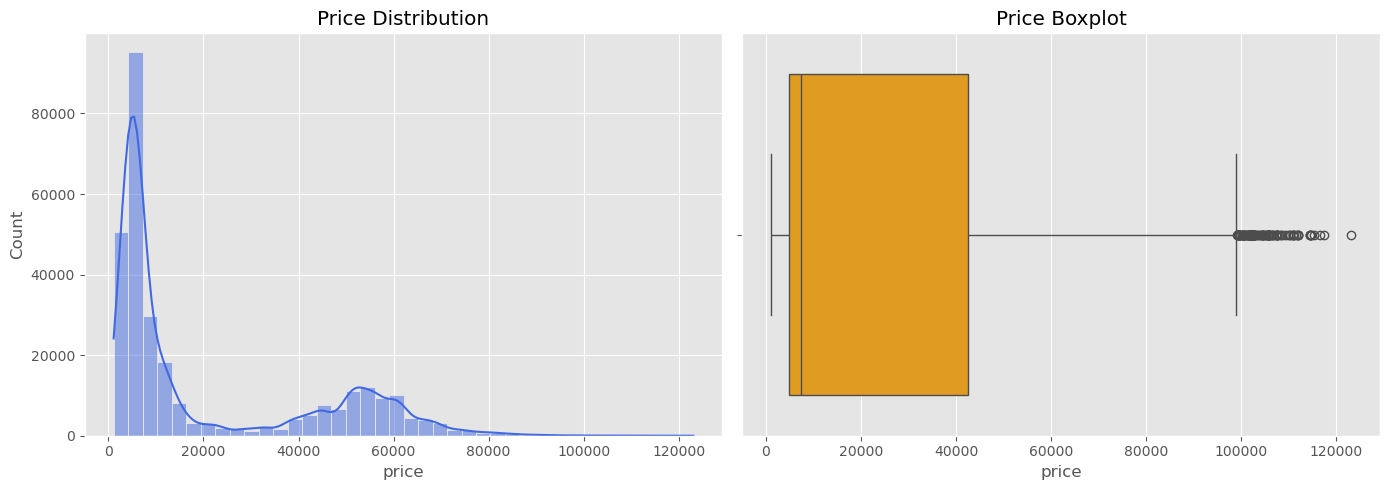

In [19]:
# ==========================================
# Target Variable Analysis
# ==========================================

# Summary Statistics
display(eda_df["price"].describe().to_frame().T)

# Mean & Median
print(f"Mean Price   : {eda_df["price"].mean():,.2f}")
print(f"Median Price : {eda_df["price"].median():,.2f}") 
print(f"skewness     : {eda_df["price"].median():,.2f}") 
print(f"Kurtosis     : {eda_df["price"].median():,.2f}") 

# Visulization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Distribution Plot
sns.histplot(
    eda_df["price"],
    kde=True,
    bins=40,
    color="royalblue",
    ax=ax[0]
)

ax[0].set_title("Price Distribution")

# Boxplot
sns.boxplot(
    x=eda_df["price"],
    color="orange",
    ax=ax[1]
)

ax[1].set_title("Price Boxplot")

plt.tight_layout()
plt.show()

# Bivariate Analysis (Feature vs Price)

## Objective

The objective of this analysis is to understand how different features influence the ticket price.

We compare each important categorical feature with the target variable (**Price**) to identify:

- Price variations across categories.
- High-priced and low-priced categories.
- Features that have a strong impact on ticket prices.
- Business insights for pricing strategy.

The following features will be analyzed:

- Airline
- Class
- Stops
- Departure Time
- Arrival Time

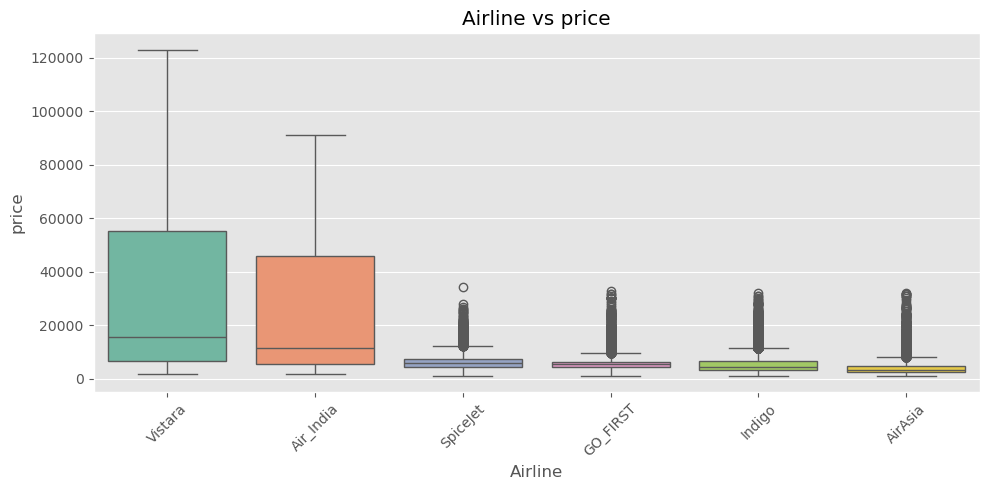

,Average Price
airline,
Vistara,30396.54
Air_India,23507.02
SpiceJet,6179.28
GO_FIRST,5652.01
Indigo,5324.22
AirAsia,4091.07


----------------------------------------------------------------------------------------------------


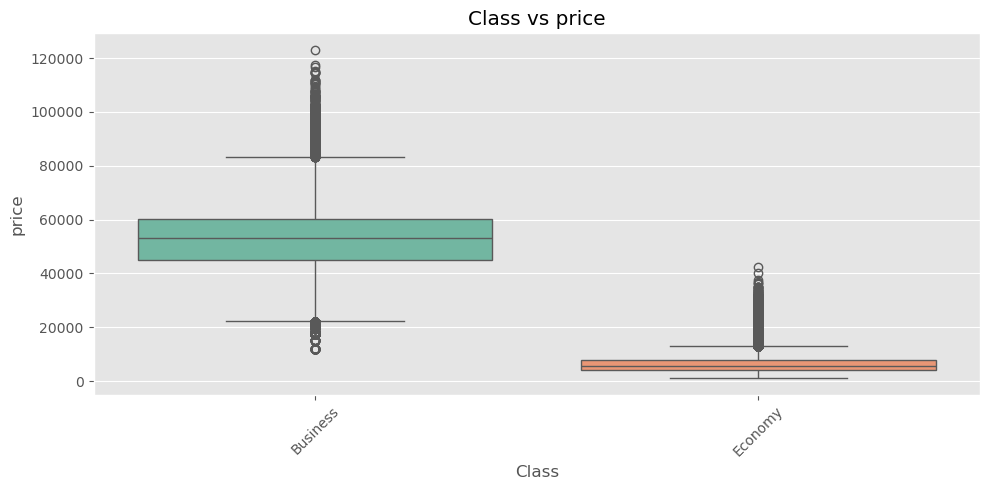

,Average Price
class,
Business,52540.08
Economy,6572.34


----------------------------------------------------------------------------------------------------


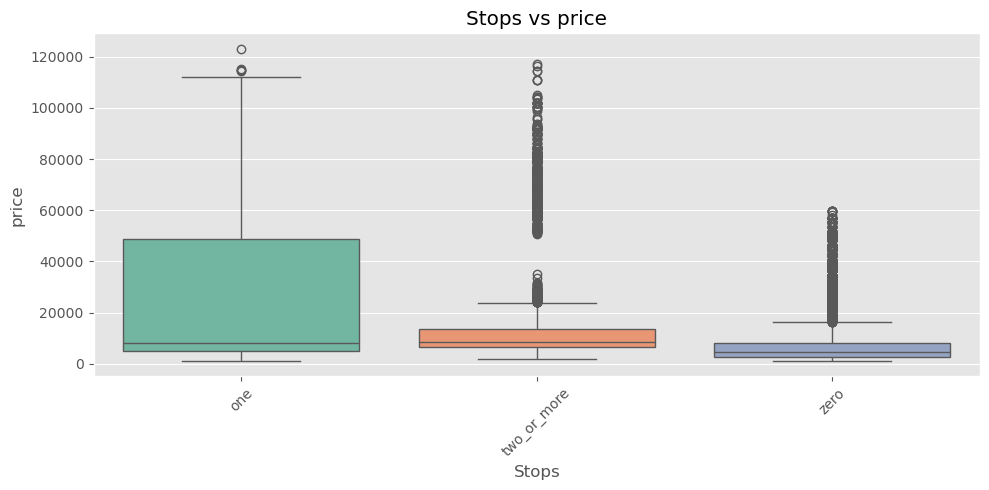

,Average Price
stops,
one,22900.99
two_or_more,14113.45
zero,9375.94


----------------------------------------------------------------------------------------------------


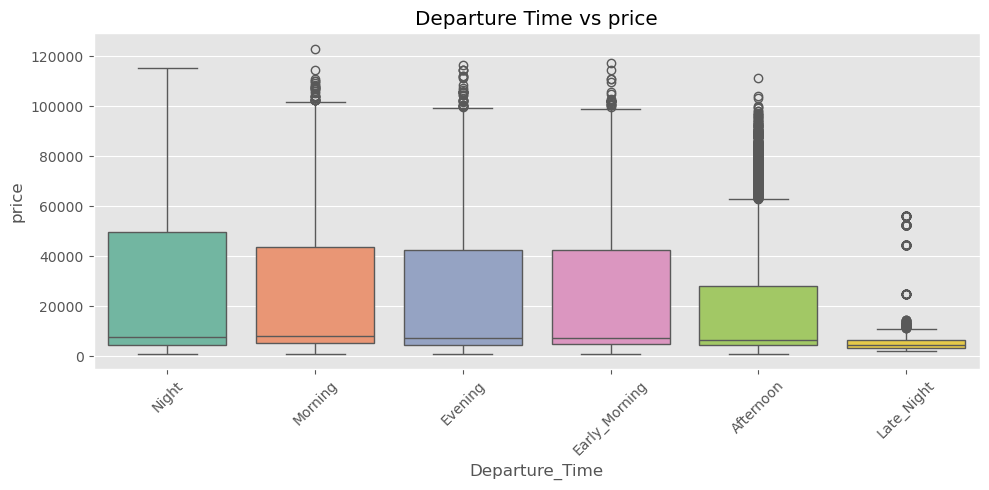

,Average Price
departure_time,
Night,23062.15
Morning,21630.76
Evening,21232.36
Early_Morning,20370.68
Afternoon,18179.20
Late_Night,9295.30


----------------------------------------------------------------------------------------------------


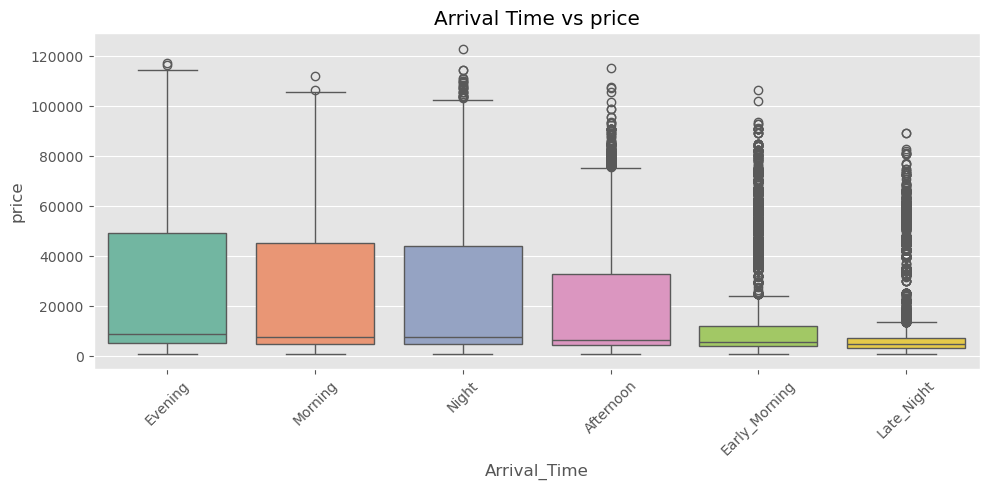

,Average Price
arrival_time,
Evening,23044.37
Morning,22231.08
Night,21586.76
Afternoon,18494.60
Early_Morning,14993.14
Late_Night,11284.91


----------------------------------------------------------------------------------------------------


In [20]:
# ==========================================
# Bivariate Analysis (Categorical vs Price)
# ==========================================

features =[
    "airline",
    "class",
    "stops",
    "departure_time",
    "arrival_time"
]

for feature in features:

    plt.figure(figsize=(10,5))

    order = (
        eda_df.groupby(feature)["price"]
            .mean()
            .sort_values(ascending=False)
            .index
    )

    sns.boxplot(
        data=eda_df,
        x=feature,
        y="price",
        order=order,
        palette="Set2"
    )


    plt.title(f"{feature.replace('_',' ').title()} vs price")
    plt.xlabel(feature.replace(" "," ").title())
    plt.ylabel("price")
    plt.xticks(rotation=45)


    plt.tight_layout()
    plt.show()

    # Average Price table
    display(
        eda_df.groupby(feature)["price"]
            .mean()
            .sort_values(ascending=False)
            .round(2)
            .to_frame("Average Price")
    )

    print("-"*100)

# Numerical Features vs Price

## Objective

The objective of this analysis is to understand the relationship between numerical features and the target variable (**Price**).

We analyze:

- Duration vs Price
- Days Left vs Price

This analysis helps us to:

- Identify trends between variables.
- Detect linear or non-linear relationships.
- Observe data spread and outliers.
- Understand which numerical features are important for price prediction.

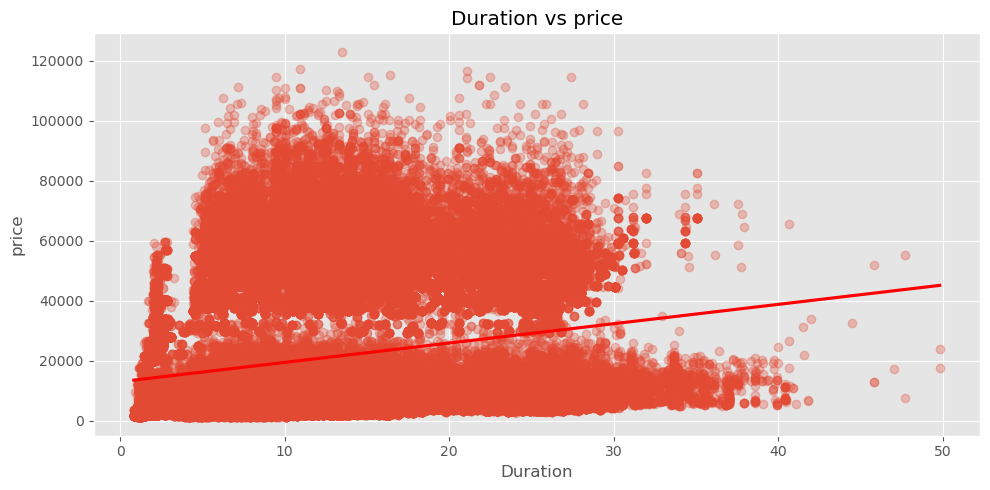

Correlation between duration and Price : 0.20
----------------------------------------------------------------------------------------------------


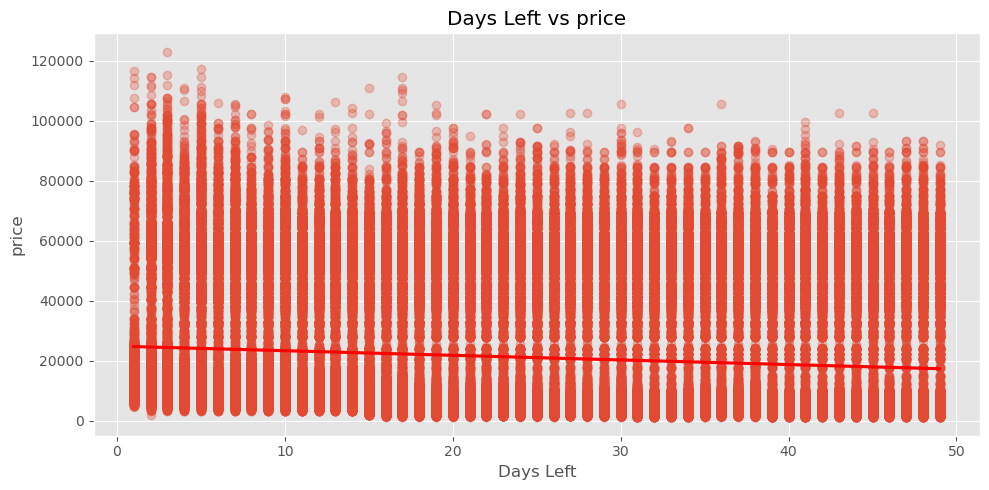

Correlation between days_left and Price : -0.09
----------------------------------------------------------------------------------------------------


In [21]:
# ==========================================
# Numerical Features vs Price
# ==========================================

num_features = ["duration", "days_left"]

for feature in num_features:

    plt.figure(figsize=(10,5))

    sns.regplot(
        data=eda_df,
        x=feature,
        y="price",
        scatter_kws={"alpha":0.3},
        line_kws={"color":"red"}
    )

    plt.title(f"{feature.replace('_',' ').title()} vs price")
    plt.xlabel(feature.replace("_"," ").title())
    plt.ylabel("price")

    plt.tight_layout()
    plt.show()

    # correlation with price
    corr = eda_df[[feature, "price"]].corr().iloc[0,1]

    print(f"Correlation between {feature} and Price : {corr:.2f}")

    print("-"*100)

# Correlation Analysis

## Objective

Correlation analysis measures the strength and direction of the relationship between numerical variables.

This analysis helps us to:

- Identify features that are strongly related to the target variable.
- Detect multicollinearity between numerical features.
- Understand feature importance before model building.

**Correlation Range**

- +1 → Perfect Positive Correlation
- 0 → No Correlation
- -1 → Perfect Negative Correlation

,duration,days_left,price
duration,1.000000,-0.039157,0.204222
days_left,-0.039157,1.000000,-0.091949
price,0.204222,-0.091949,1.000000


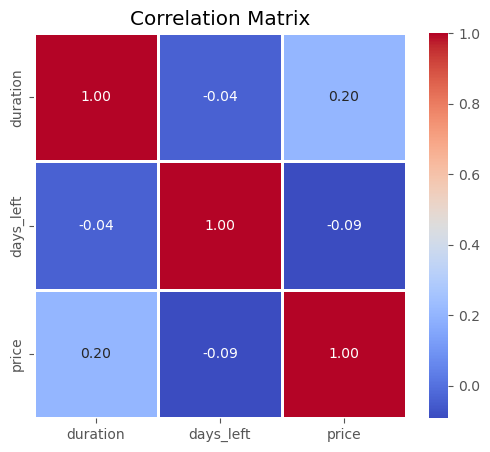

In [23]:
# ==========================================
# Correlation Analysis
# ==========================================

# NUmerical Columns
num_cols = ["duration", "days_left", "price"]

# Correlation Matrix
corr_matrix = eda_df[num_cols].corr()

display(corr_matrix)

# Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=1
)

plt.title("Correlation Matrix")

plt.show()

# EDA Summary & Key Findings

## Objective

The purpose of this section is to summarize the important findings obtained during Exploratory Data Analysis (EDA).

These insights will help in:

- Selecting useful features.
- Planning feature engineering.
- Choosing appropriate preprocessing techniques.
- Building a better machine learning model.

# Key Business Insights

### 1. Airline
- Different airlines have significantly different ticket prices.
- Premium airlines generally charge higher fares than budget airlines.

### 2. Ticket Class
- Business class tickets are considerably more expensive than Economy class.
- Ticket class appears to be one of the strongest predictors of price.

### 3. Number of Stops
- Non-stop flights usually have higher ticket prices.
- Flights with more stops generally cost less.

### 4. Flight Duration
- Longer duration flights tend to have higher ticket prices.
- Duration shows a positive relationship with price.

### 5. Days Left
- Ticket price changes with the number of days left before departure.
- Booking timing plays an important role in airline pricing.

---

# Machine Learning Insights

- Both numerical and categorical features contribute to ticket price prediction.
- Categorical features must be encoded before model training.
- Numerical features will be evaluated for scaling depending on the algorithm.
- Outliers observed in the target variable will be further investigated during preprocessing.
- The dataset is suitable for supervised regression models.

---

# Next Steps

The next notebook will focus on:

1. Data Cleaning
2. Feature Engineering
3. Encoding
4. Feature Selection
5. Data Preprocessing Pipeline